## Lab 2
#### Name: Madhura Likhar
#### Section : C3
#### Roll no.:C2_22

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("housing.csv")

In [3]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


In [5]:
df.shape

(20640, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [7]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [8]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [9]:
df["total_bedrooms"].fillna(df["total_bedrooms"].median(), inplace=True)

In [10]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [11]:
df.drop("ocean_proximity", axis=1, inplace=True)

In [12]:
df.duplicated().sum()

np.int64(0)

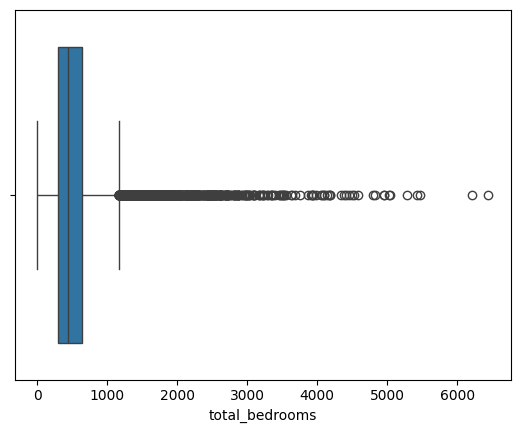

In [13]:
import seaborn as sns
sns.boxplot(x=df["total_bedrooms"])
plt.show()

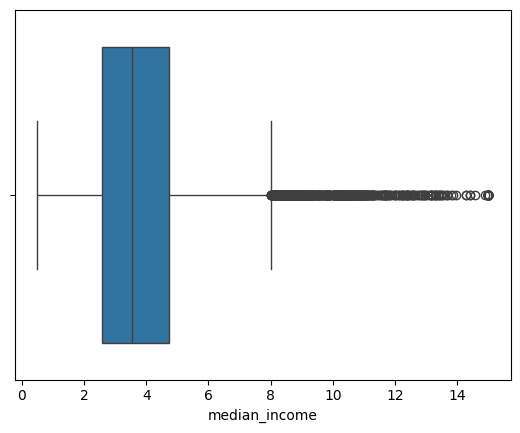

In [14]:
sns.boxplot(x=df["median_income"])
plt.show()

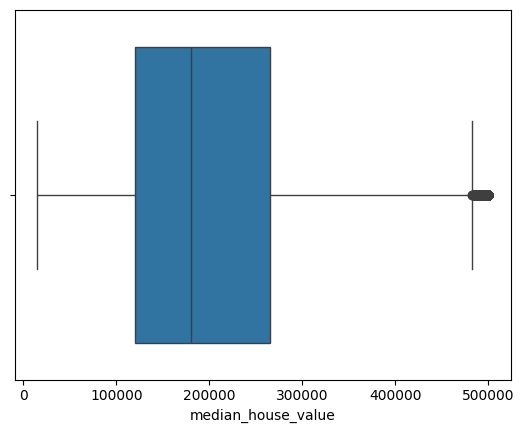

In [15]:
sns.boxplot(x=df["median_house_value"])
plt.show()

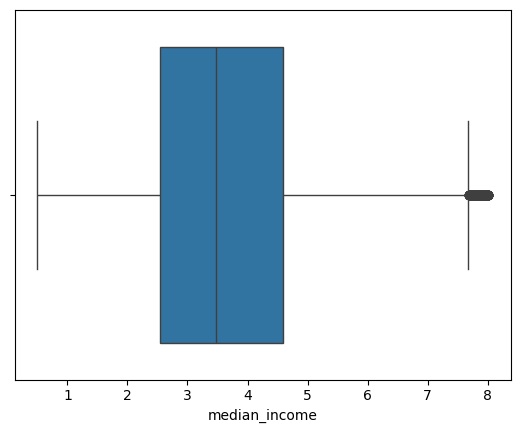

In [16]:
Q1 = df["median_income"].quantile(0.25)
Q3 = df["median_income"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["median_income"] >= lower) &
        (df["median_income"] <= upper)]

sns.boxplot(x=df["median_income"])
plt.show()

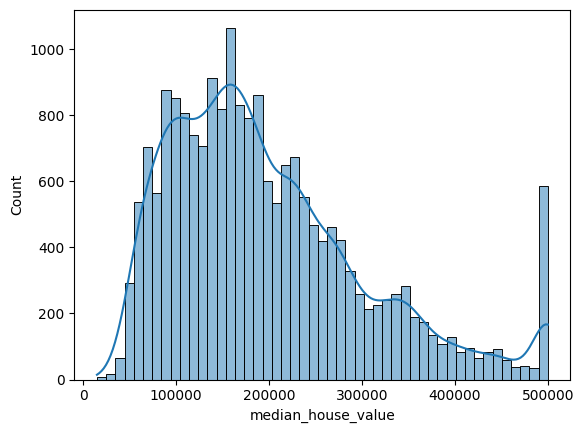

In [17]:
# univariant analysis
sns.histplot(df["median_house_value"], kde=True)
plt.show()

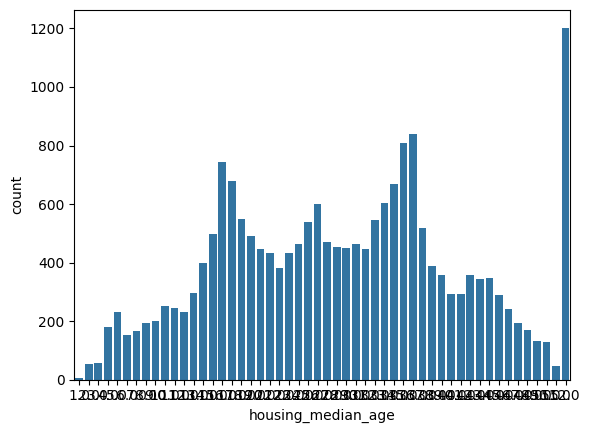

In [18]:
#univarient analysis
sns.countplot(x="housing_median_age", data=df)
plt.show()

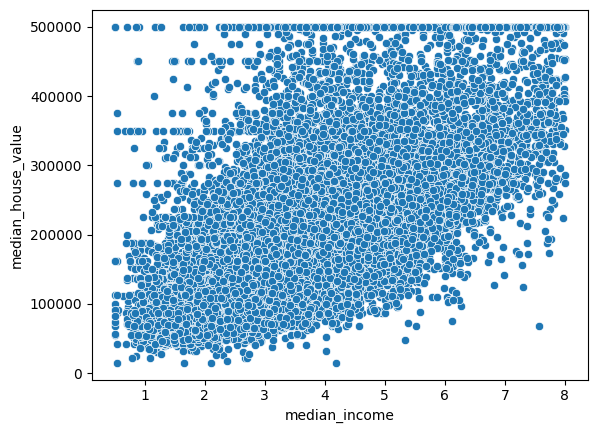

In [19]:
#bivariant analysis
sns.scatterplot(x="median_income", y="median_house_value", data=df)
plt.show()

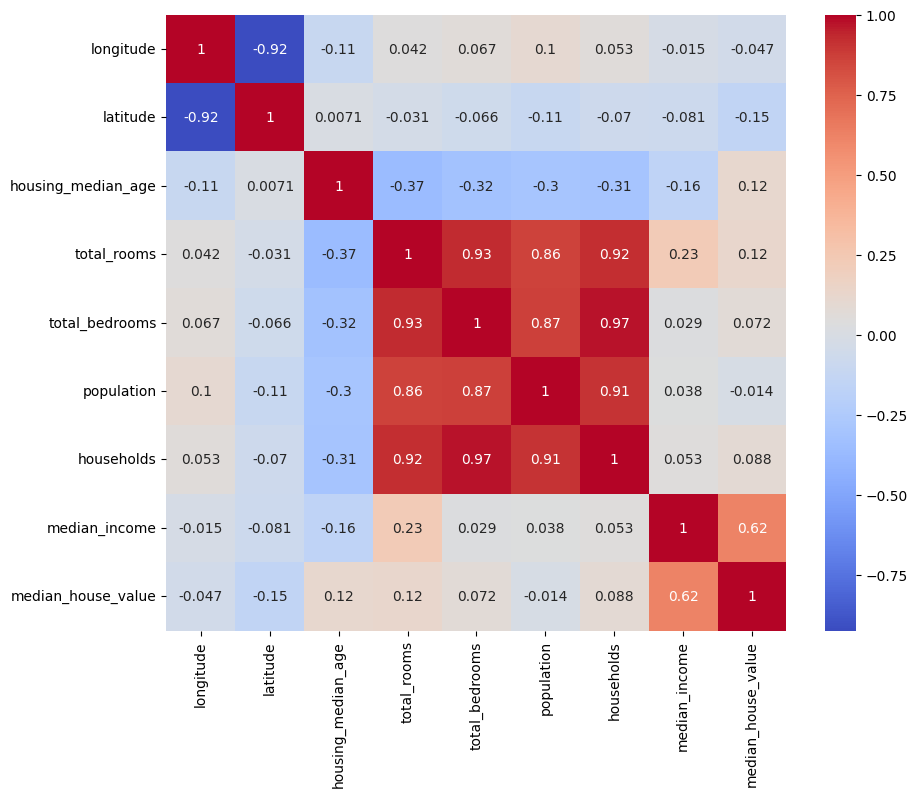

In [20]:
# Correlation Heatmap
plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include=["number"])
sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap="coolwarm")
plt.show()

In [21]:
# Feature Scaling
scaler = StandardScaler()
df[["median_income", "median_house_value"]] = scaler.fit_transform(
    df[["median_income", "median_house_value"]]
)

In [22]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

In [23]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [24]:
print(X_train.shape)

(15967, 8)


In [25]:
print(X_test.shape)

(3992, 8)


In [26]:
print(y_train.shape)

(15967,)


In [27]:
print(y_test.shape)

(3992,)


In [28]:
X.head(15)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,2.418701
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,1.334147
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,0.126914
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,0.254967
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,0.001212
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,-0.360978
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,-1.059425
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,0.022778
10,-122.26,37.85,52.0,2202.0,434.0,910.0,402.0,-0.305148
11,-122.26,37.85,52.0,3503.0,752.0,1504.0,734.0,-0.259866


### Multiple Linear regression

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [30]:
X=df.drop('median_house_value',axis=1)
y=df['median_house_value']

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
mir = LinearRegression()
mir.fit(X_train, y_train)

LinearRegression()

In [33]:
y_pred = mir.predict(X_test)

In [34]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R-squared:", r2)

Mean Absolute Error: 0.47799505630769124
Mean Squared Error: 0.44309707002981935
Root Mean Squared Error: 0.6656553688131865
R-squared: 0.5688207115513191


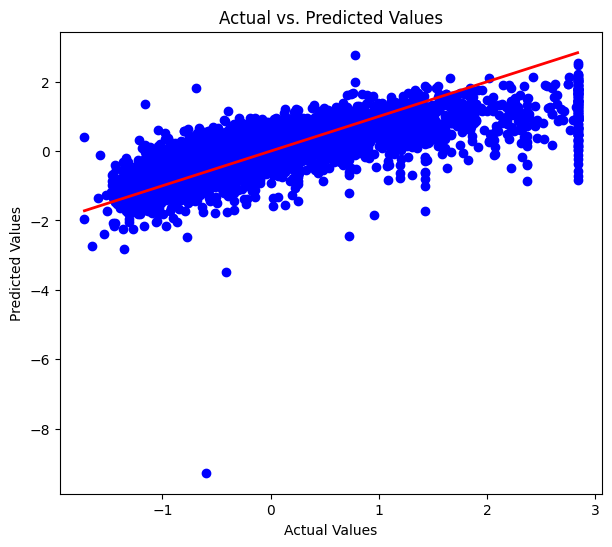

In [35]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, color="blue")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red", linewidth=2)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")

plt.show()

### Hyperparameters Tunning

In [36]:
from sklearn.model_selection import GridSearchCV

In [37]:
lr=LinearRegression()

In [38]:
lr_params={
    'fit_intercept':[True,False],
    'positive':[True,False]
}

In [39]:
grid_search = GridSearchCV(
    estimator=lr,
    param_grid=lr_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

In [40]:
grid_search.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=LinearRegression(), n_jobs=-1,
             param_grid={'fit_intercept': [True, False],
                         'positive': [True, False]},
             scoring='r2')

In [41]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'fit_intercept': True, 'positive': False}


In [42]:
{'fit_intercept':True,
 'positive': False}

{'fit_intercept': True, 'positive': False}

In [43]:
print("Best Cross Validation Score:")
print(grid_search.best_score_)

Best Cross Validation Score:
0.5822319280700188


In [44]:
best_model=grid_search.best_estimator_

In [45]:
LinearRegression(
    fit_intercept=True,
    positive=False
    )

LinearRegression()

In [46]:
y_pred=best_model.predict(X_test)

In [47]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
print("R2 Score:",r2)

MAE: 0.47799505630769124
MSE: 0.44309707002981935
RMSE: 0.6656553688131865
R2 Score: 0.5688207115513191


In [48]:
print(best_model)

LinearRegression()


In [49]:
result=grid_search.cv_results_

for mean_score,params in zip(result['mean_test_score'],result['params']):
    print(params,"R^2=", round(mean_score,4))

{'fit_intercept': True, 'positive': True} R^2= 0.4516
{'fit_intercept': True, 'positive': False} R^2= 0.5822
{'fit_intercept': False, 'positive': True} R^2= 0.451
{'fit_intercept': False, 'positive': False} R^2= 0.5238


### Ridge Regression

In [50]:
from sklearn.linear_model import Ridge

In [51]:
ridge =Ridge()

ridge.fit(X_train,y_train)
ridge_pred=ridge.predict(X_test)
print("Default Ridge R^2:" ,r2_score(y_test,ridge_pred))

Default Ridge R^2: 0.5688165961776156


In [52]:
param_grid={'alpha':[0.001,0.01,0.1,1,10,100]}

In [53]:
grid_ridge=GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

In [54]:
grid_ridge.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=Ridge(), n_jobs=-1,
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10, 100]},
             scoring='r2')

In [55]:
print("Best Alpha:")
print(grid_ridge.best_params_)

Best Alpha:
{'alpha': 10}


In [56]:
print(grid_ridge.best_score_)

0.5822321195037032


In [57]:
best_ridge=grid_ridge.best_estimator_

ridge_pred=best_ridge.predict(X_test)

In [58]:
print("MAE", mean_absolute_error(y_test,ridge_pred))
print("MSE", mean_squared_error(y_test,ridge_pred))
print("RMSE", np.sqrt(mean_squared_error(y_test,ridge_pred)))
print("R2 Score", r2_score(y_test,ridge_pred))

MAE 0.47800342993490175
MSE 0.44313971890813103
RMSE 0.665687403296871
R2 Score 0.568779209780607


### Lasso Regression

In [59]:
from sklearn.linear_model import Lasso

In [60]:
param_grid={
    'alpha':[0.001,
             0.01,
             0.1,
             1,
             10]
}

In [61]:
grid_lasso = GridSearchCV(
    Lasso(max_iter=5000),
    param_grid,
    cv=5,
    scoring='r2'
)

grid_lasso.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=Lasso(max_iter=5000),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10]}, scoring='r2')

In [62]:
print(grid_lasso.best_params_)

{'alpha': 0.001}


In [63]:
lasso_pred=grid_lasso.predict(X_test)

print(r2_score(y_test,lasso_pred))

0.5686658732637201
